<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [21]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [22]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [23]:
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


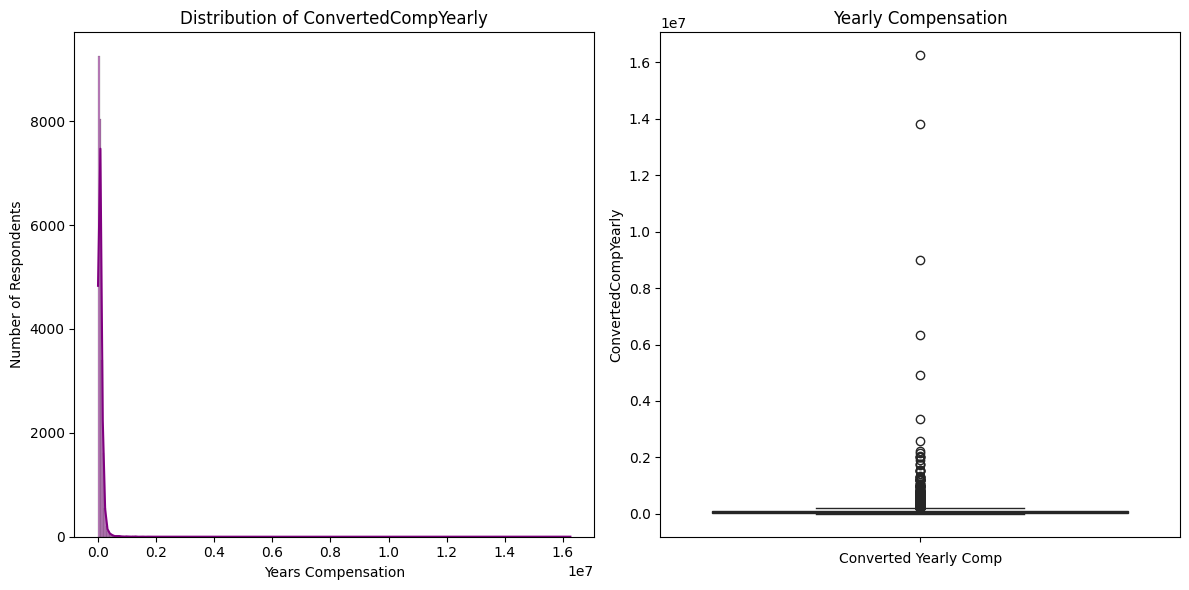

In [24]:
## Write your code here
#columns - ConvertedCompYearly (float64), ResponseId (int)
df.dtypes

#clean - 
comp_clean = df['ConvertedCompYearly'].dropna()
print(comp_clean.describe())

#Histogram plot - with KED

sns.set_style = ('whitegrid') #makes it clearer

#subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.histplot(comp_clean, bins = 'auto', kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of ConvertedCompYearly')
axes[0].set_xlabel('Years Compensation')
axes[0].set_ylabel('Number of Respondents')

#box plot for outliers
sns.boxplot(comp_clean, ax=axes[1], color='green')
axes[1].set_title('Yearly Compensation')
axes[1].set_xlabel('Converted Yearly Comp')
plt.tight_layout()

plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [25]:
df['ConvertedCompYearly'] #checking columns

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
65432   NaN
65433   NaN
65434   NaN
65435   NaN
65436   NaN
Name: ConvertedCompYearly, Length: 65437, dtype: float64

In [26]:
## Write your code here
#columns = Employment,ConvertedCompYearly

#clean
comp_clean = df.dropna(subset=['ConvertedCompYearly'])

#filter
Full_time = comp_clean[comp_clean['Employment'] == "Employed, full-time"]

#calculate the median
median_comp = Full_time['ConvertedCompYearly'].median()

print(median_comp)


69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [27]:
## Write your code here
df['Country'].unique() #str

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

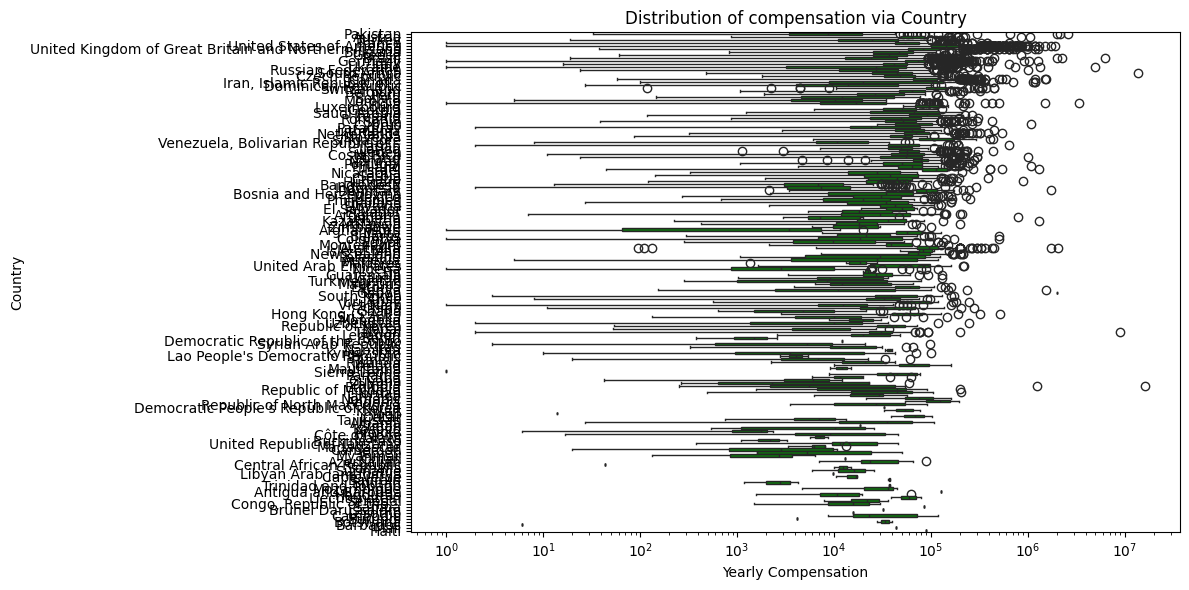

In [28]:
## Write your code here
#compare compensation across countries, columns = Country (str), ConvertedCompYears (float)

#clean the columns
clean_df = df.dropna(subset=['ConvertedCompYearly', 'Country'])

#count the number of responses per country
Country_count = clean_df['Country'].value_counts()

#create box plot
plt.figure(figsize=(12,6))
sns.boxplot(
    data = clean_df,
    x = 'ConvertedCompYearly',
    y = 'Country',
    color='green')
    
plt.title('Distribution of compensation via Country')
plt.xlabel('Yearly Compensation')
plt.ylabel('Country')
plt.xscale('log')
plt.tight_layout()
plt.show()

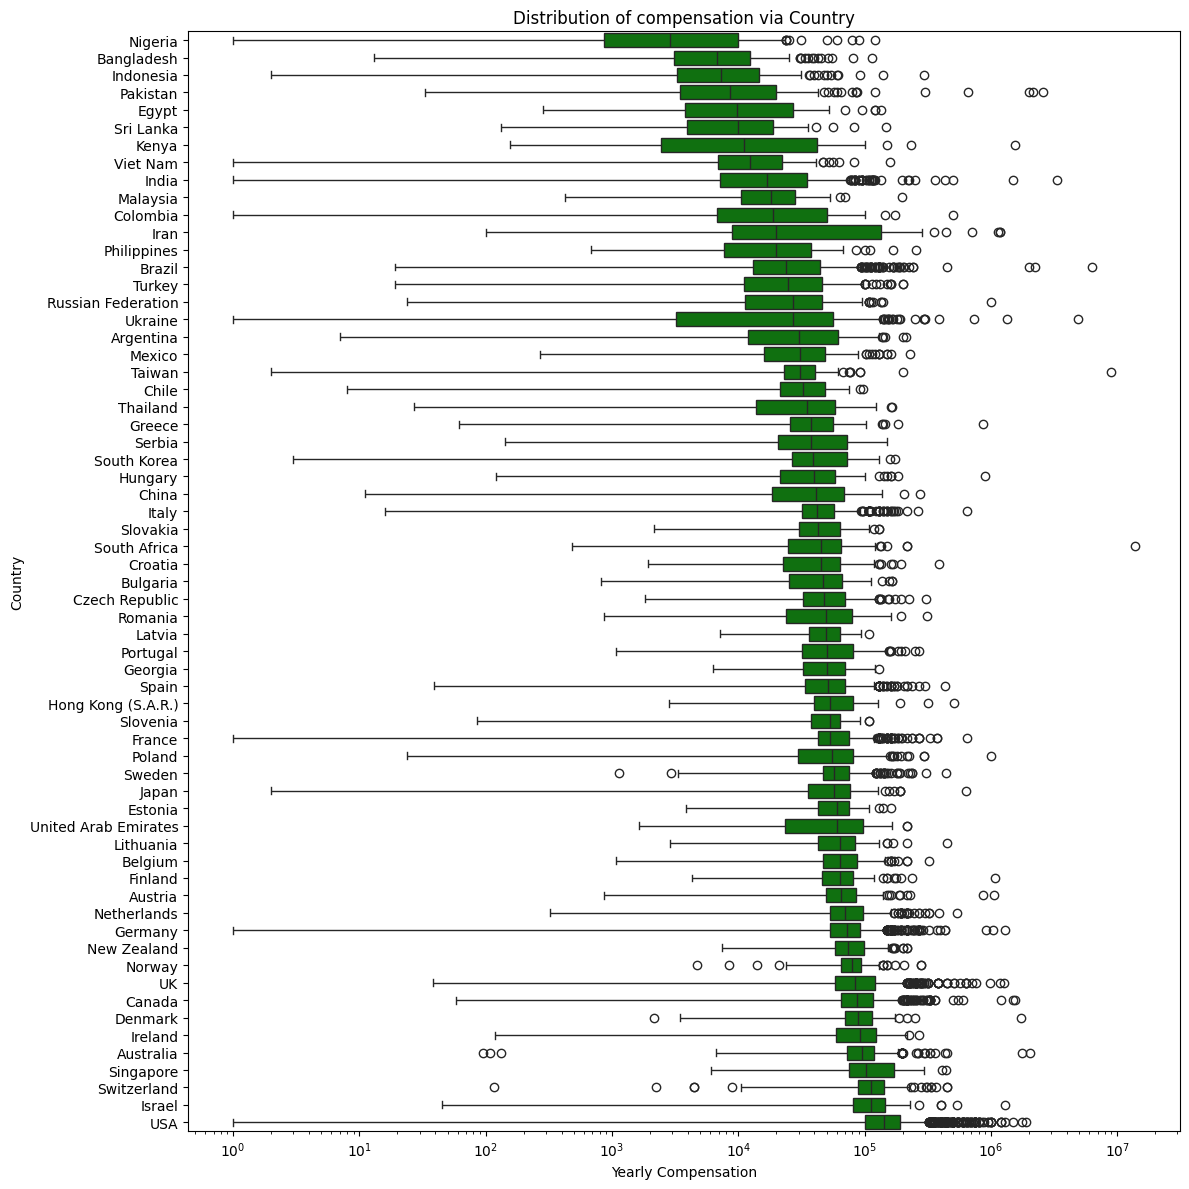

In [29]:
# Very messy and unable to read, need to clean 
clean_df = df.dropna(subset=['ConvertedCompYearly', 'Country']).copy()

# As the previous attempt was so hard to read, 1/ I will remove <=0 values, 2/ adjust countries so low response countries are not included.
#3 adjust the country names to be shorter
 
clean_df = clean_df[clean_df['ConvertedCompYearly'] > 0]
 
clean_df['short_country'] = (clean_df['Country'].str.replace('United States of America', 'USA', regex=False).str.replace('United Kingdom of Great Britain and Northern Ireland', 'UK', regex=False)
                       .str.replace(r',.*', '', regex=True).str.strip())

#count the number of responses per country
Country_count = clean_df['short_country'].value_counts()

top_countries = Country_count[Country_count >=40].index #(may need to adjust this, trial and error)(originally started at 20)
df_filtered = clean_df[clean_df['short_country'].isin(top_countries)].copy()

#sort by median for better readability
country_order = (df_filtered.groupby('short_country')['ConvertedCompYearly'].median().sort_values().index)
#create box plot
plt.figure(figsize=(12,12))
sns.boxplot(
    data = df_filtered,
    x = 'ConvertedCompYearly',
    y = 'short_country',
    order=country_order,
    color='green')
    
plt.title('Distribution of compensation via Country')
plt.xlabel('Yearly Compensation')
plt.ylabel('Country')
plt.xscale('log')
plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [30]:
## Write your code here
comp = df['ConvertedCompYearly']
comp = comp[(comp > 0)].dropna()

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

print('IQR:', IQR)

#defining the bounds
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR


#create a new df without the outliers
New_df = df[df['ConvertedCompYearly'].between(upper_bound, lower_bound) & (df['ConvertedCompYearly'] > 0)].copy()

print('Origional DataFrame size:', df.shape)
print('New DataFrame size:', New_df.shape)
        

IQR: 75259.5
Origional DataFrame size: (65437, 114)
New DataFrame size: (0, 114)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.153182        0.020156
WorkExp                         0.153182  1.000000       -0.028839
JobSatPoints_1                  0.020156 -0.028839        1.000000


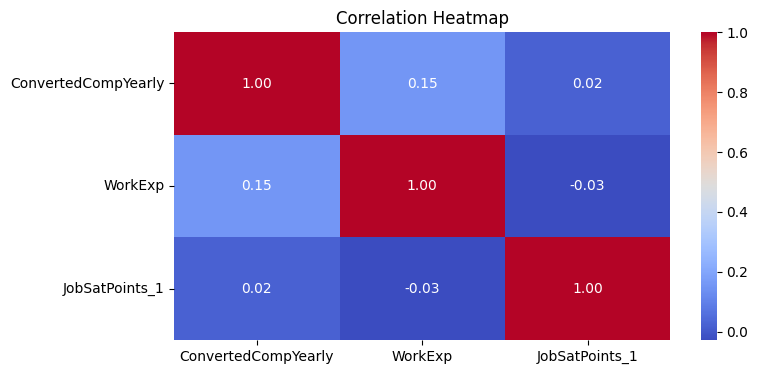

In [31]:
## Write your code here
#Columns = WorkExp (float), ConveredCompYearly (float), JobSatPoints_1 (float)

#calculate the corrolation between above columns - drop nan

df = df.dropna(subset=['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1'])

Correlation = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].corr()

print(Correlation)

#Results - salary vs experience = 0.153 - weak positive relationship
#salary vs jobsat - 0.020 - essentially no relationship
# experience vs jobsat - -0.028 - very weak negative relationship
#conclusion - the variables are largely independent, there is no strong linear relationship
#0.0 – 0.1 No correlation, 0.1 – 0.3 Weak, 0.3 – 0.5 Moderate, 0.5+ Strong

#creat heatmap to show this from the results.
plt.figure(figsize=(8,4))
sns.heatmap(Correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


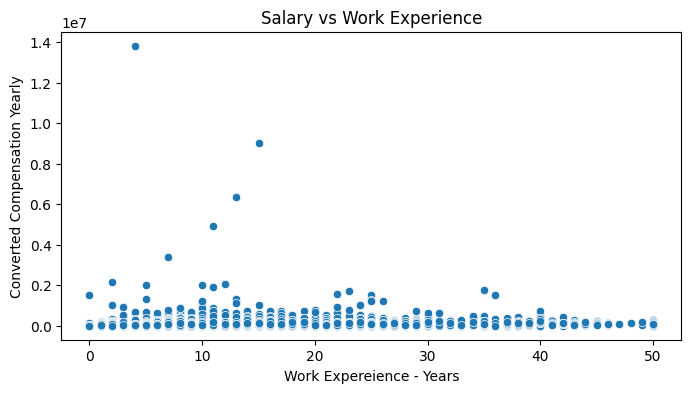

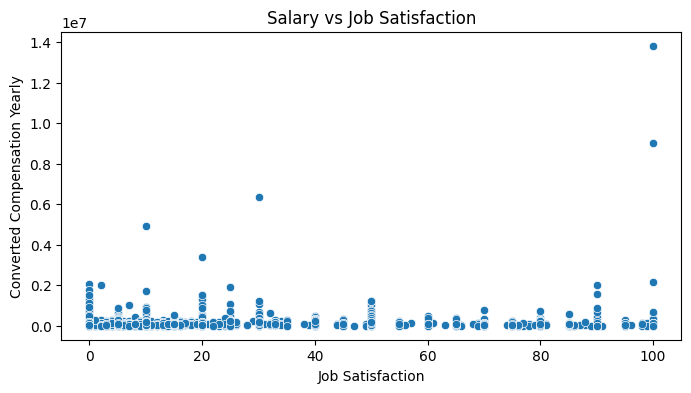

In [33]:
## Write your code here - Scatterplot
#ConvertedCompYearly and WorkExp
plt.figure(figsize=(8,4))
sns.scatterplot(x='WorkExp', y='ConvertedCompYearly', data=df)
plt.title('Salary vs Work Experience')
plt.xlabel('Work Expereience - Years')
plt.ylabel('Converted Compensation Yearly')
plt.show()

#ConvertedCompYearly and WorkExp
plt.figure(figsize=(8,4))
sns.scatterplot(x='JobSatPoints_1', y='ConvertedCompYearly', data=df)
plt.title('Salary vs Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Converted Compensation Yearly')
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
